# Computational Carpentry Project

**Group C**  
**Team members:** Pamela Sampaa Afaki, Sarhini Nour, Alice Bolard, Chiara Bifulco

## Part A - Data structures and functions

We first load the periodic-table data and use it to build a molecular mass calculator. 

### 1. Loading the periodic table

The CSV file is loaded with pandas. We display the first rows to check the column names and values.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from fractions import Fraction

periodic_table = pd.read_csv("periodic_table.csv")
periodic_table.head()

print("hi")

hi


### 2. Creating the atomic mass dictionary

The element symbols are used as keys and their atomic masses as values. This lets us look up a mass directly from a symbol.

In [28]:
atomic_masses = dict(zip(periodic_table["Symbol"], periodic_table["AtomicMass"]))


{symbol: atomic_masses[symbol] for symbol in ["H", "C", "O", "Ca", "Cu"]}

print(atomic_masses)

{'H': 1.008, 'He': 4.0026, 'Li': 7.0, 'Be': 9.012183, 'B': 10.81, 'C': 12.011, 'N': 14.007, 'O': 15.999, 'F': 18.99840316, 'Ne': 20.18, 'Na': 22.9897693, 'Mg': 24.305, 'Al': 26.981538, 'Si': 28.085, 'P': 30.973762, 'S': 32.07, 'Cl': 35.45, 'Ar': 39.9, 'K': 39.0983, 'Ca': 40.08, 'Sc': 44.95591, 'Ti': 47.867, 'V': 50.9415, 'Cr': 51.996, 'Mn': 54.93804, 'Fe': 55.84, 'Co': 58.93319, 'Ni': 58.693, 'Cu': 63.55, 'Zn': 65.4, 'Ga': 69.723, 'Ge': 72.63, 'As': 74.92159, 'Se': 78.97, 'Br': 79.9, 'Kr': 83.8, 'Rb': 85.468, 'Sr': 87.62, 'Y': 88.90584, 'Zr': 91.22, 'Nb': 92.90637, 'Mo': 95.95, 'Tc': 96.90636, 'Ru': 101.1, 'Rh': 102.9055, 'Pd': 106.42, 'Ag': 107.868, 'Cd': 112.41, 'In': 114.818, 'Sn': 118.71, 'Sb': 121.76, 'Te': 127.6, 'I': 126.9045, 'Xe': 131.29, 'Cs': 132.905452, 'Ba': 137.33, 'La': 138.9055, 'Ce': 140.116, 'Pr': 140.90766, 'Nd': 144.24, 'Pm': 144.91276, 'Sm': 150.4, 'Eu': 151.964, 'Gd': 157.2, 'Tb': 158.92535, 'Dy': 162.5, 'Ho': 164.93033, 'Er': 167.26, 'Tm': 168.93422, 'Yb': 173.05

### 3. Molecular mass of a simple formula

A regular expression separates each element symbol from the number after it. When there is no number, the count is taken as 1. This first version is meant for formulas without parentheses or hydration dots.

For a molecule containing $n_i$ atoms of element $i$, its molecular mass is

$$M = \sum_i n_i A_i,$$

where $A_i$ is the atomic mass of element $i$. This follows from additivity: every atom of element $i$ contributes $A_i$, so $n_i$ identical atoms contribute $n_iA_i$. Adding the contributions of all elements gives the total mass.

In [15]:
def molecular_mass_simple(formula):
    tokens = re.findall(r"([A-Z][a-z]?)(\d*)", formula)
    total = 0
    for symbol, number in tokens:
        count = int(number) if number else 1
        total += atomic_masses[symbol] * count
    return total

for formula in ["H2O", "C6H12O6"]:
    print(f"{formula}: {molecular_mass_simple(formula):.3f} g/mol")

H2O: 18.015 g/mol
C6H12O6: 180.156 g/mol


The values agree with the usual molar masses. This first version works for formulas without parentheses.

### 4. Parentheses using recursive programming

For a formula such as `Ca(OH)2`, the 2 multiplies everything inside the parentheses. A recursive parser is useful here because a group inside parentheses is handled in the same way as the complete formula. It also allows nested groups.

If a group has composition $\{n_i\}$ and is followed by a multiplier $k$, repeating the group $k$ times gives $kn_i$ atoms of every element. Its mass is therefore

$$\sum_i (kn_i)A_i = k\sum_i n_iA_i.
$$
The recursive method applies this same rule at each level of parentheses. The innermost group is counted first, multiplied by its coefficient, and added to the surrounding group. This proves the method for nested parentheses by induction on the nesting depth.

In [16]:
def add_atoms(total, atoms, multiplier=1):
    for element, number in atoms.items():
        total[element] = total.get(element, 0) + number * multiplier


def parse_section(formula, position=0):
    atoms = {}

    while position < len(formula) and formula[position] != ")":
        if formula[position] == "(":
            group, position = parse_section(formula, position + 1)
            position += 1  # skip the closing parenthesis
            number = ""
            while position < len(formula) and formula[position].isdigit():
                number += formula[position]
                position += 1
            add_atoms(atoms, group, int(number or 1))

        else:
            element = formula[position]
            position += 1
            if position < len(formula) and formula[position].islower():
                element += formula[position]
                position += 1

            number = ""
            while position < len(formula) and formula[position].isdigit():
                number += formula[position]
                position += 1
            atoms[element] = atoms.get(element, 0) + int(number or 1)

    return atoms, position


def parse_formula_with_parentheses(formula):
    atoms, position = parse_section(formula)
    return atoms


def molecular_mass_parentheses(formula):
    composition = parse_formula_with_parentheses(formula)
    return sum(atomic_masses[symbol] * count for symbol, count in composition.items())

for formula in ["Ca(OH)2", "Al2(SO4)3", "K4(ON(SO3)2)2"]:
    print(formula, parse_formula_with_parentheses(formula),
          f"{molecular_mass_parentheses(formula):.3f} g/mol")

Ca(OH)2 {'Ca': 1, 'O': 2, 'H': 2} 74.094 g/mol
Al2(SO4)3 {'Al': 2, 'S': 3, 'O': 12} 342.161 g/mol
K4(ON(SO3)2)2 {'K': 4, 'O': 14, 'N': 2, 'S': 4} 536.673 g/mol


The nested example checks that recursion works beyond a single pair of parentheses. The parser first counts the atoms, then the mass calculation uses that composition.

### 5. Coordinated water

Hydrates are written as separate parts, for example `CuSO4.5H2O`. We split at the dot, read an optional coefficient at the beginning of each part, and use the recursive parser for the remaining formula. The function also accepts the middle-dot symbol `·`.

A hydrate written as $X\cdot mH_2O$ contains one formula unit of $X$ and $m$ water molecules. Since molecular masses add,

$$M(X\cdot mH_2O)=M(X)+mM(H_2O).$$

This is why the multiplier at the start of each dot-separated part must multiply the whole part.

In [17]:
def parse_formula(formula):
    total_composition = {}
    parts = formula.replace("·", ".").split(".")

    for part in parts:
        match = re.match(r"(\d*)(.*)", part)
        multiplier = int(match.group(1) or 1)
        part_formula = match.group(2)
        atoms = parse_formula_with_parentheses(part_formula)
        add_atoms(total_composition, atoms, multiplier)

    return dict(total_composition)


def molecular_mass(formula):
    composition = parse_formula(formula)
    return sum(atomic_masses[symbol] * count for symbol, count in composition.items())

for formula in ["CuSO4.5H2O", "CuSO4·5H2O", "MgSO4.7H2O"]:
    print(formula, parse_formula(formula), f"{molecular_mass(formula):.3f} g/mol")

CuSO4.5H2O {'Cu': 1, 'S': 1, 'O': 9, 'H': 10} 249.691 g/mol
CuSO4·5H2O {'Cu': 1, 'S': 1, 'O': 9, 'H': 10} 249.691 g/mol
MgSO4.7H2O {'Mg': 1, 'S': 1, 'O': 11, 'H': 14} 246.476 g/mol


Both notations for copper(II) sulfate pentahydrate give the same composition and mass, as expected.

## Part B - Stoichiometry and reaction balancing

### 1. Reaction balancer

For each element, the number of atoms on the reactant side must equal the number on the product side. These conditions form a homogeneous linear system. Reactant columns are positive and product columns are negative. The singular vector associated with the smallest singular value gives a solution, which is converted to the smallest set of positive integers.

Let $a_{ij}$ be the number of atoms of element $i$ in species $j$, and let $c_j$ be its stoichiometric coefficient. Conservation of element $i$ requires

$$\sum_{j\in R} a_{ij}c_j = \sum_{j\in P} a_{ij}c_j.
$$
Moving the product terms to the left gives

$$\sum_j A_{ij}c_j=0,$$

where product columns of $A$ have a negative sign. For all elements at once, this is $A\mathbf{c}=\mathbf{0}$. Therefore a balancing vector lies in the null space of $A$. SVD identifies this null-space direction, and scaling it to the smallest positive integers gives the usual stoichiometric coefficients.

In [18]:
def parse_simple_composition(formula):
    tokens = re.findall(r"([A-Z][a-z]?)(\d*)", formula)
    composition = {}
    for symbol, number in tokens:
        composition[symbol] = composition.get(symbol, 0) + int(number or 1)
    return composition


def balance_reaction(reactants, products):
    formulas = reactants + products
    compositions = [parse_simple_composition(f) for f in formulas]
    elements = sorted({element for comp in compositions for element in comp})

    matrix = np.zeros((len(elements), len(formulas)), dtype=float)
    for row, element in enumerate(elements):
        for col, composition in enumerate(compositions):
            sign = 1 if col < len(reactants) else -1
            matrix[row, col] = sign * composition.get(element, 0)

    U, S, Vh = np.linalg.svd(matrix)
    vector = abs(Vh[-1])
    vector = vector / min(vector)
    fractions = [Fraction(float(value)).limit_denominator(1000) for value in vector]
    common_denominator = np.lcm.reduce([f.denominator for f in fractions])
    coefficients = [int(f * common_denominator) for f in fractions]
    common_factor = np.gcd.reduce(coefficients)
    coefficients = [c // common_factor for c in coefficients]
    return coefficients


def format_reaction(reactants, products, coefficients):
    n_reactants = len(reactants)
    left = " + ".join(f"{c if c != 1 else ''}{f}" for c, f in zip(coefficients[:n_reactants], reactants))
    right = " + ".join(f"{c if c != 1 else ''}{f}" for c, f in zip(coefficients[n_reactants:], products))
    return f"{left} -> {right}"

We test the function on water formation, iron oxidation and ethane combustion.

In [19]:
test_reactions = [
    (["H2", "O2"], ["H2O"]),
    (["Fe", "O2"], ["Fe2O3"]),
    (["C2H6", "O2"], ["CO2", "H2O"]),
]

balanced_examples = []
for reactants, products in test_reactions:
    coefficients = balance_reaction(reactants, products)
    balanced_examples.append((reactants, products, coefficients))
    print(format_reaction(reactants, products, coefficients))

2H2 + O2 -> 2H2O
4Fe + 3O2 -> 2Fe2O3
2C2H6 + 7O2 -> 4CO2 + 6H2O


The three outputs match the expected balanced equations: $2H_2 + O_2 \rightarrow 2H_2O$, $4Fe + 3O_2 \rightarrow 2Fe_2O_3$, and $2C_2H_6 + 7O_2 \rightarrow 4CO_2 + 6H_2O$.

### 2. Mass conservation check

The coefficients and molecular masses are used to calculate the total mass represented on each side. A small numerical tolerance is included because atomic masses are stored as decimal numbers.

For the reactants, the total mass represented by the equation is

$$M_R=\sum_{j\in R}c_jM_j
=\sum_i A_i\left(\sum_{j\in R}c_ja_{ij}\right).$$

The same calculation for the products gives

$$M_P=\sum_i A_i\left(\sum_{j\in P}c_ja_{ij}\right).$$

A balanced equation has the same number of atoms of every element on both sides. The expressions in parentheses are therefore equal for each $i$, which proves that $M_R=M_P$.

In [20]:
def total_stoichiometric_mass(molecules):
    return sum(molecular_mass(formula) * coefficient
               for formula, coefficient in molecules.items())


def mass_is_conserved(reactant_coefficients, product_coefficients, tolerance=1e-9):
    reactant_mass = total_stoichiometric_mass(reactant_coefficients)
    product_mass = total_stoichiometric_mass(product_coefficients)
    return abs(reactant_mass - product_mass) <= tolerance


def coefficient_dictionaries(reactants, products, coefficients):
    split = len(reactants)
    return (dict(zip(reactants, coefficients[:split])),
            dict(zip(products, coefficients[split:])))


for reactants, products, coefficients in balanced_examples:
    left, right = coefficient_dictionaries(reactants, products, coefficients)
    left_mass = total_stoichiometric_mass(left)
    right_mass = total_stoichiometric_mass(right)
    conserved = mass_is_conserved(left, right)
    print(format_reaction(reactants, products, coefficients))
    print(f"  reactants = {left_mass:.6f}, products = {right_mass:.6f}, conserved = {conserved}")

2H2 + O2 -> 2H2O
  reactants = 36.030000, products = 36.030000, conserved = True
4Fe + 3O2 -> 2Fe2O3
  reactants = 319.354000, products = 319.354000, conserved = True
2C2H6 + 7O2 -> 4CO2 + 6H2O
  reactants = 284.126000, products = 284.126000, conserved = True


All three checks return `True`. This is also an independent check that the integer coefficients produced by the balancing function are consistent.

## Part C - Simulation and modeling

### 1. Monte Carlo estimate of $\pi$

Random points are generated in the square $[-1,1] \times [-1,1]$. A point is inside the unit circle when $x^2+y^2 \leq 1$. Since the circle occupies a fraction $\pi/4$ of the square, four times the fraction of points inside estimates $\pi$.

The unit circle has area $\pi$ and the surrounding square has area $2\times2=4$. A uniformly sampled point therefore has probability

$$P(\text{inside})=\frac{\pi}{4}.
$$
Define $I_k=1$ when point $k$ is inside the circle and $I_k=0$ otherwise. For $N$ points, the observed fraction inside is

$$\overline I_N=\frac{1}{N}\sum_{k=1}^{N}I_k.
$$
By the law of large numbers, $\overline I_N$ approaches $P(\text{inside})=\pi/4$ as $N$ grows. Multiplying by 4 gives the estimator

$$\widehat\pi_N=\frac{4}{N}\sum_{k=1}^{N}I_k.
$$
It is unbiased because $E[\widehat\pi_N]=4E[I_k]=4(\pi/4)=\pi$.

In [21]:
def estimate_pi(N, seed=None):
    rng = np.random.default_rng(seed)
    points = rng.uniform(-1, 1, size=(N, 2))
    inside = np.sum(points[:, 0]**2 + points[:, 1]**2 <= 1)
    return 4 * inside / N

pi_estimate = estimate_pi(100_000, seed=3)
print(f"Estimated pi: {pi_estimate:.6f}")
print(f"Absolute error: {abs(pi_estimate - np.pi):.6f}")

Estimated pi: 3.146200
Absolute error: 0.004607


To see the convergence clearly, the next calculation uses one sequence of random points and records the running estimate at increasing values of $N$.

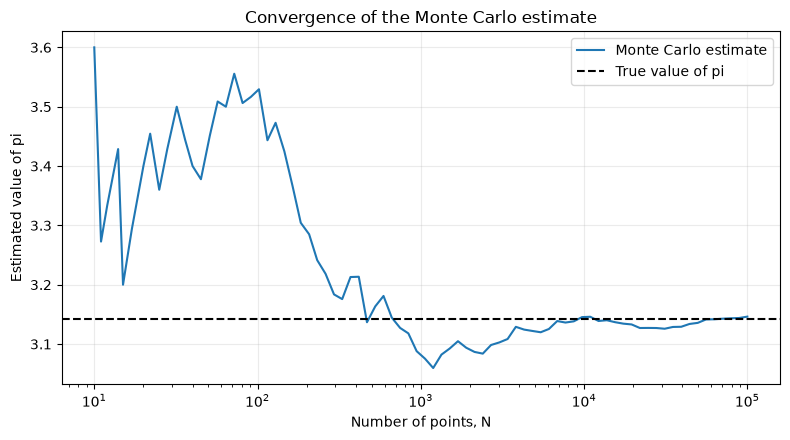

In [22]:
rng = np.random.default_rng(3)
N_max = 100_000
points = rng.uniform(-1, 1, size=(N_max, 2))
inside = points[:, 0]**2 + points[:, 1]**2 <= 1
running_estimates = 4 * np.cumsum(inside) / np.arange(1, N_max + 1)
sample_sizes = np.unique(np.logspace(1, 5, 80, dtype=int))

plt.figure(figsize=(8, 4.5))
plt.plot(sample_sizes, running_estimates[sample_sizes - 1], label="Monte Carlo estimate")
plt.axhline(np.pi, color="black", linestyle="--", label="True value of pi")
plt.xscale("log")
plt.xlabel("Number of points, N")
plt.ylabel("Estimated value of pi")
plt.title("Convergence of the Monte Carlo estimate")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

The estimate fluctuates strongly when only a few points are used. As $N$ increases, the fluctuations become smaller and the estimate approaches $\pi$. It does not improve smoothly because the method is random.

### 2. Chemistry-inspired Monte Carlo simulation

We model a set of molecular collisions and assign a random energy to each one. An exponential distribution is used because it produces many low-energy collisions and fewer high-energy ones. A collision is counted as reactive when its energy exceeds a chosen threshold.

Let $J_k=1$ if collision $k$ has energy $E_k\geq E_{\mathrm{threshold}}$, and $J_k=0$ otherwise. If the true probability of exceeding the threshold is $p$, then $E[J_k]=p$. The simulated reaction probability is

$$\widehat p_M=\frac{1}{M}\sum_{k=1}^{M}J_k.
$$
Its expectation is $E[\widehat p_M]=p$, and the law of large numbers shows that $\widehat p_M$ approaches $p$ as the number of simulated collisions increases.

In [23]:
def simulate_collisions(M, threshold_energy, mean_energy=40.0, seed=None):
    rng = np.random.default_rng(seed)
    energies = rng.exponential(scale=mean_energy, size=M)
    reactive_collisions = np.count_nonzero(energies >= threshold_energy)
    probability = reactive_collisions / M
    return probability, energies, reactive_collisions

M = 100_000
threshold_energy = 60.0
probability, collision_energies, reactive_collisions = simulate_collisions(
    M, threshold_energy, mean_energy=40.0, seed=7
)

print(f"Total collisions: {M}")
print(f"Collisions above the threshold: {reactive_collisions}")
print(f"Estimated reaction probability: {probability:.4f}")

Total collisions: 100000
Collisions above the threshold: 22329
Estimated reaction probability: 0.2233


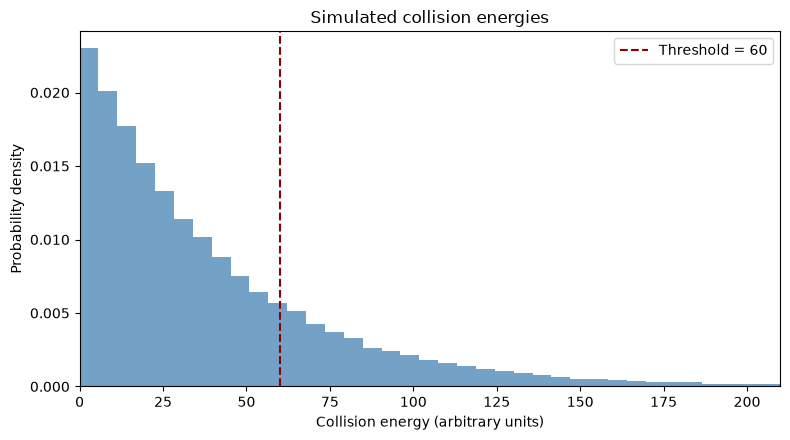

In [24]:
plt.figure(figsize=(8, 4.5))
plt.hist(collision_energies, bins=70, density=True, alpha=0.75, color="steelblue")
plt.axvline(threshold_energy, color="darkred", linestyle="--",
            label=f"Threshold = {threshold_energy:g}")
plt.xlabel("Collision energy (arbitrary units)")
plt.ylabel("Probability density")
plt.title("Simulated collision energies")
plt.xlim(0, np.percentile(collision_energies, 99.5))
plt.legend()
plt.tight_layout()
plt.show()

The estimated probability is the fraction of collisions with enough energy to pass the threshold. In this simplified model, increasing the threshold lowers the reaction probability, while increasing the mean collision energy raises it. The simulation only considers energy, so effects such as molecular orientation are not included.

## Conclusion

This project helped us understand how Python can be used to solve chemistry problems instead of only doing calculations by hand. We became more comfortable working with dictionaries, functions, loops and data from a CSV file.

The part we struggled with most was reading chemical formulas. The first function worked for simple formulas such as `H2O`, but parentheses and hydration water made it more difficult because the coefficients had to be applied to several atoms at once. We solved this by separating the problem into smaller steps and testing each version before adding the next case. Using recursion for the parentheses was challenging at first, but it made the final function work with nested groups as well.

Balancing reactions was also difficult because we had to translate atom conservation into a matrix. The SVD result did not directly give integer coefficients, so we had to convert the ratios into the smallest whole numbers. Testing the function on three different reactions and checking mass conservation helped us confirm that it was working correctly.

Finally, the Monte Carlo simulations showed us that random methods do not always give the exact same result, but become more reliable when the number of simulations increases. Overall, the project helped us improve both our Python skills and the way we break a larger problem into smaller, testable parts.
